In [ ]:
!pip install tensorflow-datasets

In [ ]:
import tensorflow_datasets as tfds

ds_train = tfds.load('emnist/letters', split='train')
ds_test = tfds.load('emnist/letters', split='test')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.Q6HKON_3.1.0/emnist-train.tfrecord-[0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.Q6HKON_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-9…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [ ]:
builder = tfds.builder('emnist/letters')
builder.download_and_prepare()

print(builder.info)

tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='/root/tensorflow_datasets/emnist/letters/3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    }),
    supervised_keys

(28, 28, 1)
25


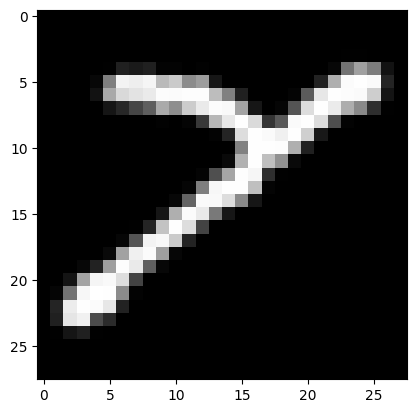

In [ ]:
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

ds_train = tfds.load(
    'emnist/letters',
    split='train',
    as_supervised=True
)

for image, label in tfds.as_numpy(ds_train.take(1)):
    print(image.shape)
    print(label)

    plt.imshow(image.squeeze(), cmap='gray')
    plt.show()

In [ ]:
import tensorflow_datasets as tfds
import numpy as np

# Load dataset
train_ds = tfds.load('emnist/letters', split='train', as_supervised=True)
test_ds = tfds.load('emnist/letters', split='test', as_supervised=True)

# Convert training data
X_train = []
y_train = []

for image, label in tfds.as_numpy(train_ds):
    X_train.append(image)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Convert testing data
X_test = []
y_test = []

for image, label in tfds.as_numpy(test_ds):
    X_test.append(image)
    y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (88800, 28, 28, 1)
Training Labels: (88800,)
Testing Images: (14800, 28, 28, 1)
Testing Labels: (14800,)


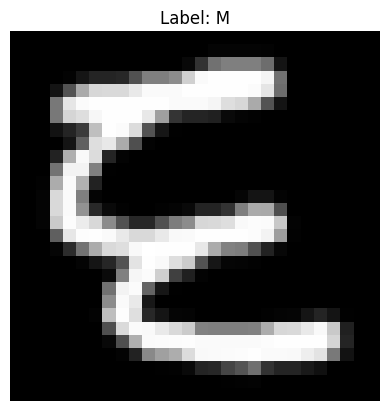

In [ ]:

import matplotlib.pyplot as plt

index = 100

plt.imshow(X_train[index].squeeze(), cmap='gray')
plt.title(f"Label: {chr(y_train[index] + 64)}")
plt.axis('off')
plt.show()

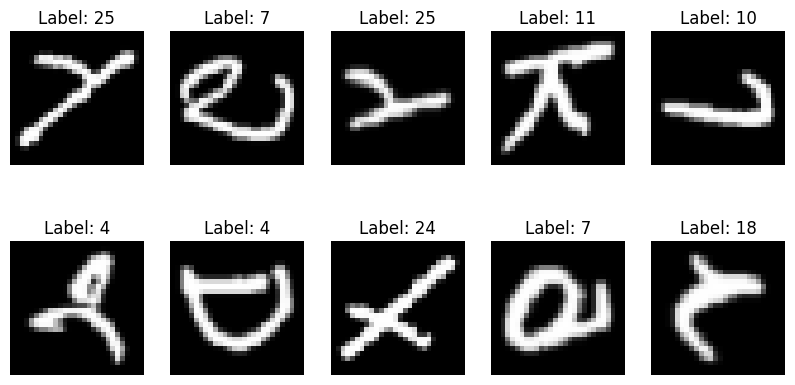

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(88800, 28, 28, 1)
(14800, 28, 28, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train,100)
y_test = to_categorical(y_test,100)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
model = Sequential()

#First Convolution Layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
#First Pooling Layer
model.add(MaxPooling2D((2,2)))

#Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))
#Second Pooling Layer
model.add(MaxPooling2D((2,2)))

#Third Convolution Layer
model.add(Conv2D(128,(3,3),activation='relu'))
#Third Pooling Layer
model.add(MaxPooling2D((2,2)))

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128,activation='relu'))

#Dropout Layer
model.add(Dropout(0.5))

#Output Layer
model.add(Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,084 (476.89 KB)

 Trainable params: 122,084 (476.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.0383 - loss: 3.3035 - val_accuracy: 0.0541 - val_loss: 3.2651
Epoch 2/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4164 - loss: 1.8824 - val_accuracy: 0.6323 - val_loss: 1.0807
Epoch 3/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.6633 - loss: 1.0441 - val_accuracy: 0.7122 - val_loss: 0.8463
Epoch 4/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7115 - loss: 0.8883 - val_accuracy: 0.7389 - val_loss: 0.7536
Epoch 5/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7394 - loss: 0.8005 - val_accuracy: 0.7651 - val_loss: 0.6886
Epoch 6/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.7591 - loss: 0.7290 - val_accuracy: 0.7736 - val_loss: 0.6551
Epoch 7/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7735 - loss: 0.6861 - val_accuracy: 0.7876 - val_loss: 0.6022
Epoch 8/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7862 - loss: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8117 - loss: 0.5320
Test Loss: 0.5320197939872742
Test Accuracy: 0.8116891980171204


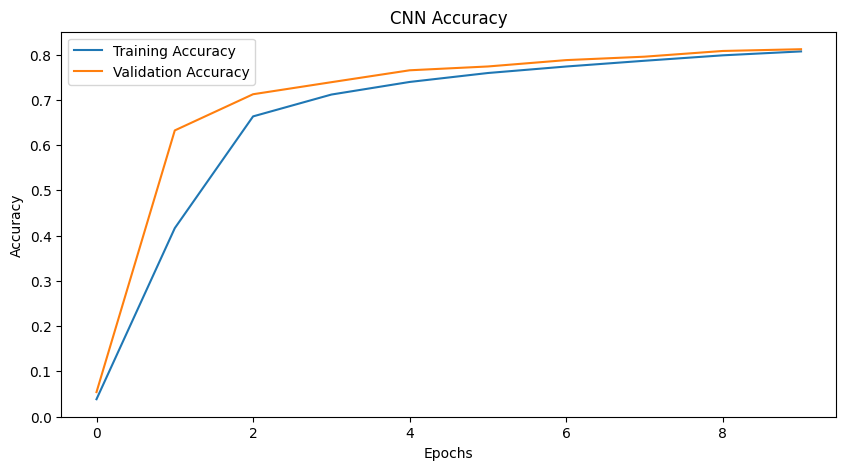

In [ ]:
#Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

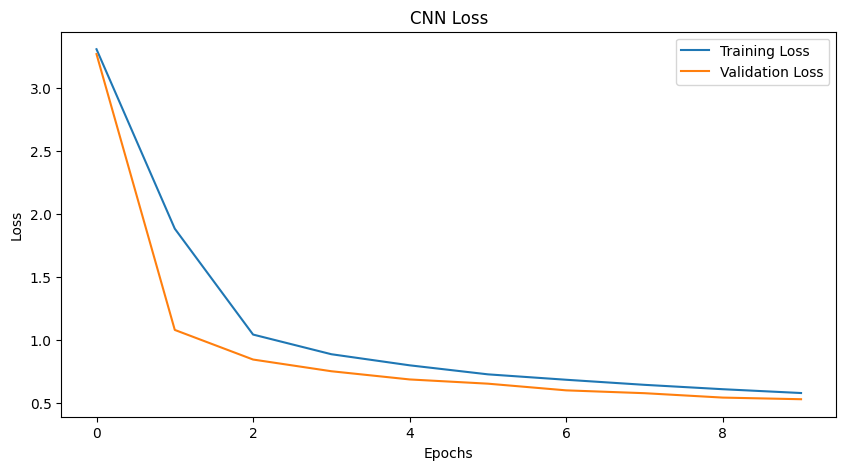

In [ ]:
#Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

In [ ]:
class_names=['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z']

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step


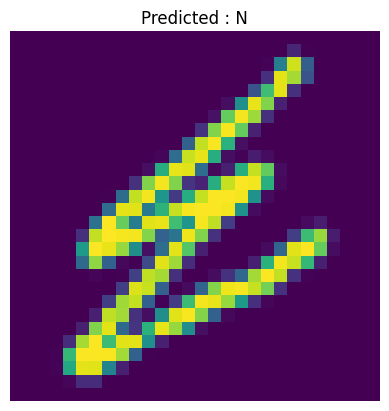

In [ ]:
sample = X_test[0]
prediction = model.predict(sample.reshape(-1,28,28,1))
predicted_class = np.argmax(prediction)
predicted_class_name = class_names[predicted_class]
plt.imshow(sample)
plt.title(f"Predicted : {predicted_class_name}")
plt.axis('off')
plt.show()

Saving Screenshot 2026-06-12 111500.png to Screenshot 2026-06-12 111500.png


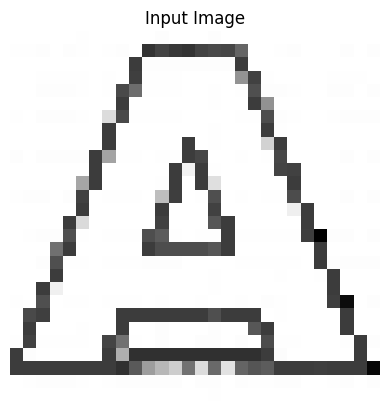

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted: A
Confidence Score: 100.0 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
import numpy as np
import matplotlib.pyplot as plt
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (28, 28))
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img = img / 255.0

plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

img = img.reshape(-1,28,28,1)
prediction = model.predict(img)
predicted_class = np.argmax(prediction)
predicted_class_name = class_names[predicted_class  ]
print(f"Predicted: {predicted_class_name}")

print(f"Confidence Score:", np.max(prediction)*100, "%")